In [2]:
#Load data
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [63]:
## For import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# KNN (K-Nearest Neighbors)
from sklearn.neighbors import KNeighborsClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier


In [5]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.059150,146.500000,32.394716,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.057253,90.348842,6.715793,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,57.000000,360.625000,50.250000,2.420000,81.000000,1.000000


In [23]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.059150,146.500000,32.394716,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.057253,90.348842,6.715793,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,57.000000,360.625000,50.250000,2.420000,81.000000,1.000000


In [7]:
## Checking whether the data contains null value or not
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
#Check zero values:

zero_check_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_check_columns:
    zeros = (data[col] == 0).sum()
    print(f"{col}: {zeros} zero values")


Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [15]:
#Replacing zeros for checking outliers

zero_check_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[zero_check_columns] = data[zero_check_columns].replace(0, np.nan)

# Verify
print(data.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 🧹 Data Cleaning Observations

- Dataset has 768 rows and 9 columns
- No actual NaN values BUT columns like Glucose, Insulin,
  BMI, BloodPressure, SkinThickness had 0 values which are
  medically impossible — treated as missing values
- Replaced 0s with NaN, then checked real outliers via boxplot
- Insulin and SkinThickness had extreme outliers likely caused
  by data entry errors — applied Winsorization (IQR capping)
- BloodPressure outliers kept as they represent real medical
  conditions like hypertension
- Filled all NaN values with median to avoid mean being
  skewed by outliers
  

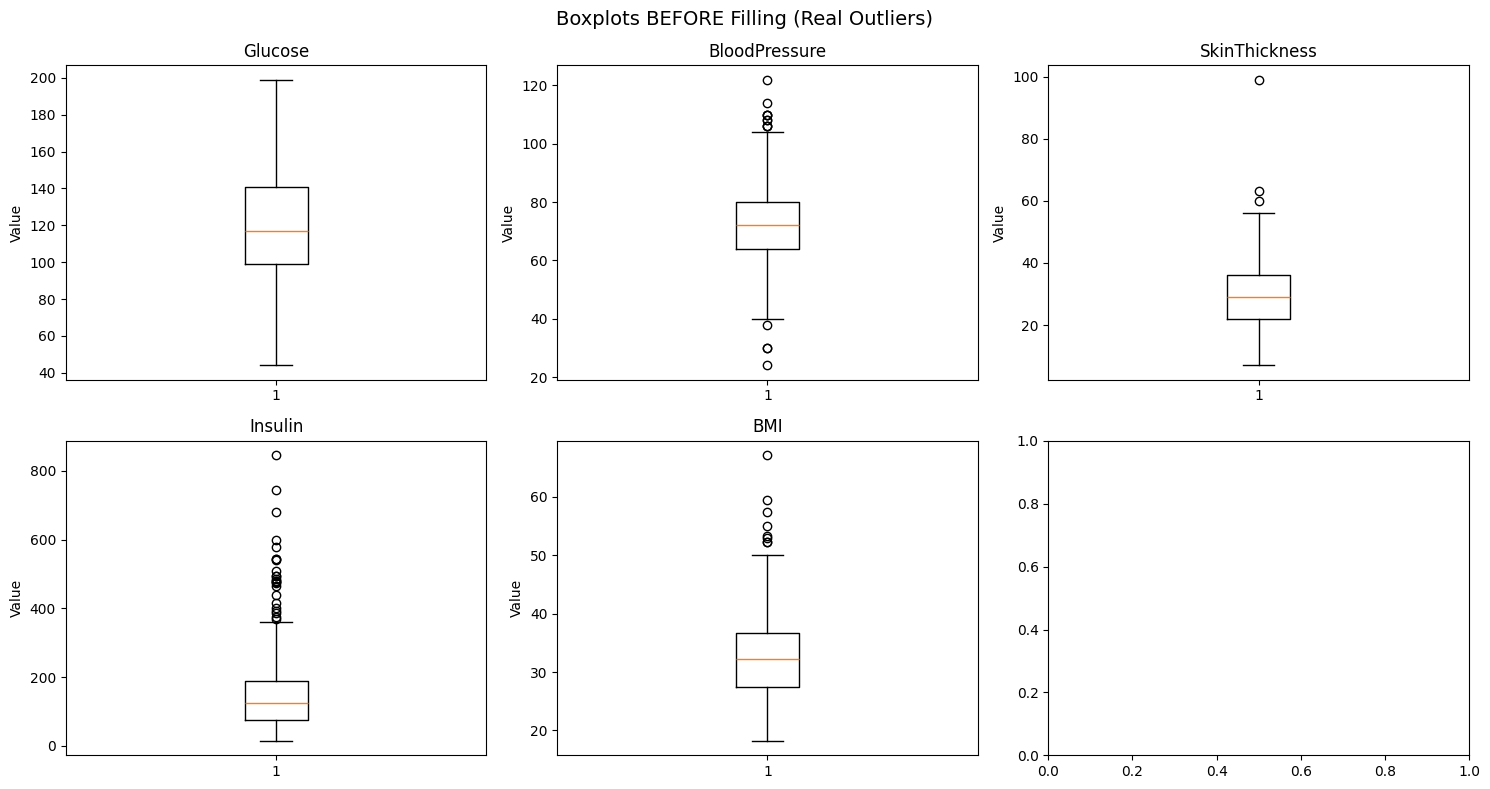

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(zero_check_columns):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots BEFORE Filling (Real Outliers)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Cap outliers using IQR upper bound for Insulin and SkinThickness
def cap_outliers(df, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)
    return data

for col in ['Insulin', 'SkinThickness', 'BMI']:
    data = cap_outliers(data, col)
    print(f"{col} capped successfully")

Insulin capped successfully
SkinThickness capped successfully
BMI capped successfully


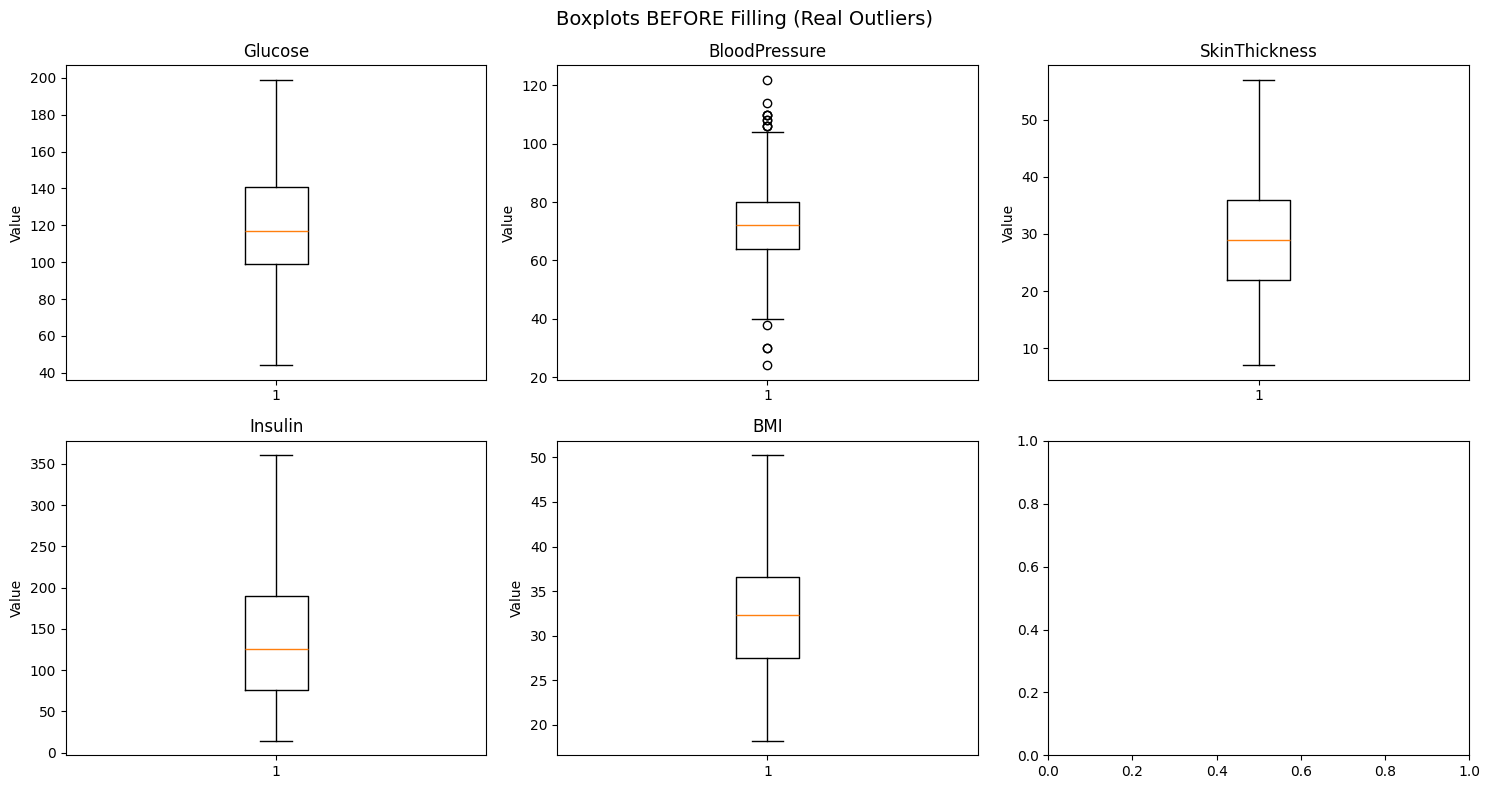

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(zero_check_columns):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots AFTER Capping Outliers', fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
# Fill remaining NaN with median
for col in zero_check_columns:
    data[col].fillna(data[col].median(), inplace=True)

# Verify no nulls remain
print("=== Final Null Check ===")
print(data.isnull().sum())

=== Final Null Check ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
BMI_Category                0
Age_Group                   0
dtype: int64


/tmp/ipykernel_818/3734335514.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [10]:
print(data['Outcome'].value_counts())
print(data['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


###Features Engineering



In [43]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

data['BMI_Category'] = data['BMI'].apply(bmi_category)
print(data['BMI_Category'].value_counts())

BMI_Category
Obese          483
Overweight     179
Normal         102
Underweight      4
Name: count, dtype: int64


In [44]:
def age_group(age):
    if age < 30:
        return 'Young'
    elif age < 50:
        return 'Middle'
    else:
        return 'Senior'

data['Age_Group'] = data['Age'].apply(age_group)
print(data['Age_Group'].value_counts())

Age_Group
Young     396
Middle    283
Senior     89
Name: count, dtype: int64


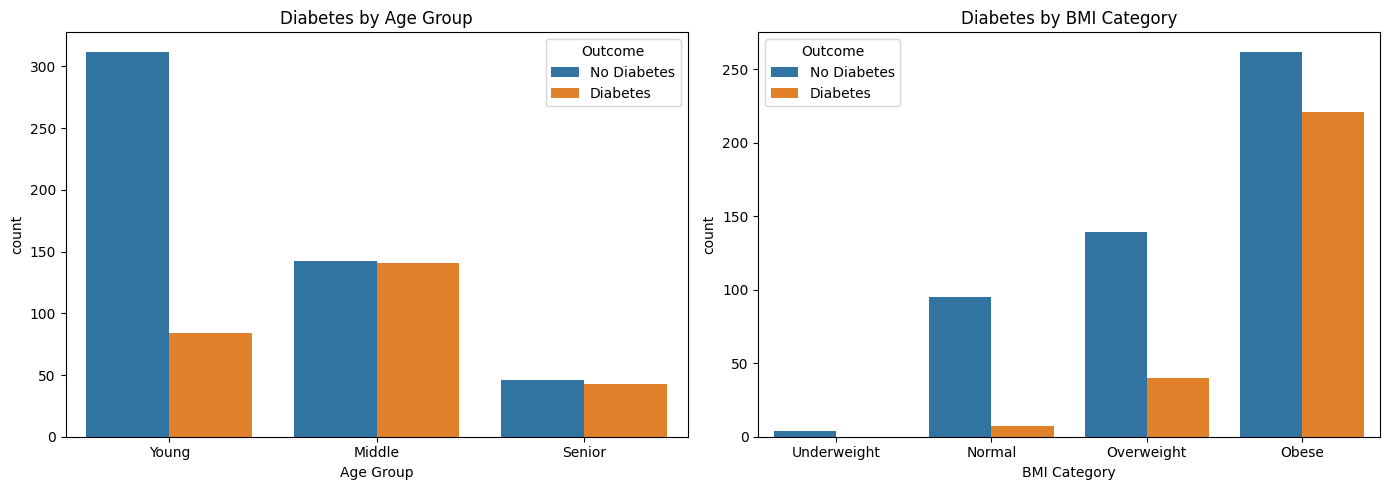

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Group plot
sns.countplot(x='Age_Group', hue='Outcome', data=data,
              ax=axes[0], order=['Young','Middle','Senior'])
axes[0].set_title('Diabetes by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])

# BMI Category plot
sns.countplot(x='BMI_Category', hue='Outcome', data=data,
              ax=axes[1], order=['Underweight','Normal','Overweight','Obese'])
axes[1].set_title('Diabetes by BMI Category')
axes[1].set_xlabel('BMI Category')
axes[1].legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

# Never guess, always calculate!
# obese = data[data['BMI_Category'] == 'Obese']['Outcome']
# print(obese.value_counts(normalize=True) * 100)

### 📊 Key Findings — Age & BMI Analysis

**Age Group:**
- Young patients (under 30) have only ~21% diabetes rate
- Middle aged patients jump to ~49% — more than double!
- Senior patients show ~48% rate, similar to middle aged
- Conclusion: Once a person crosses 30, diabetes risk nearly
  doubles regardless of further aging

**BMI Category:**
- Underweight and Normal patients have very low diabetes risk (<14%)
- Risk jumps to 22% for Overweight patients
- Obese patients show alarming 46% diabetes rate
- Conclusion: BMI is clearly one of the strongest
  predictors of diabetes in this dataset

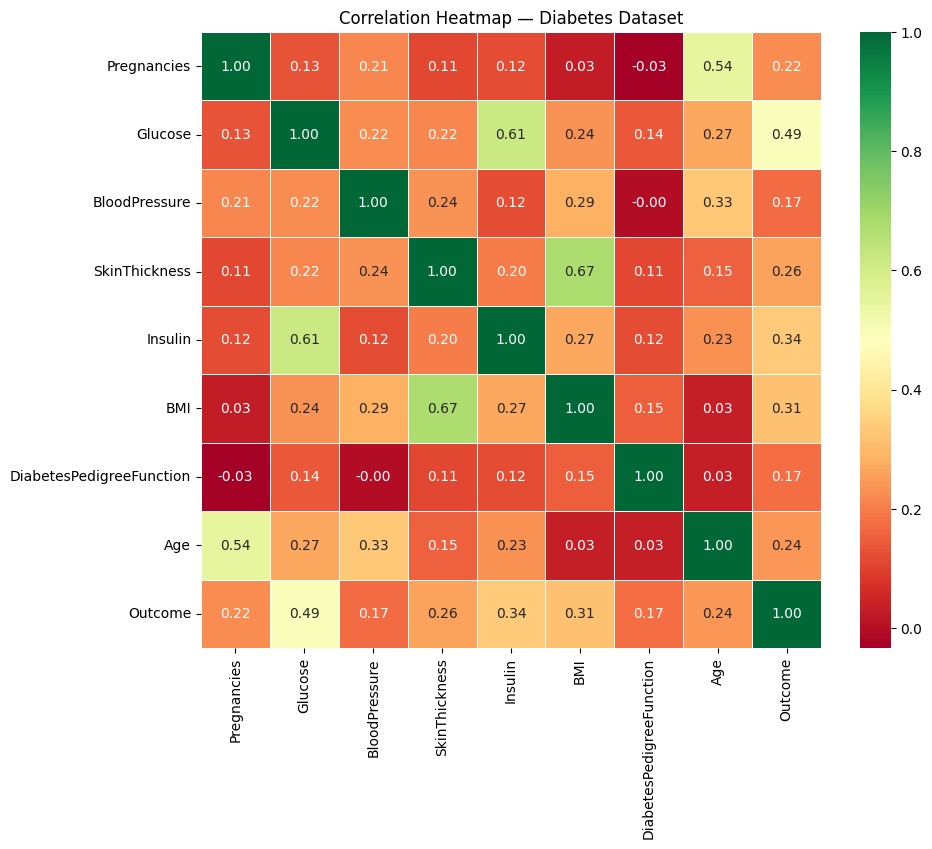

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='RdYlGn',
            fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap — Diabetes Dataset')
plt.show()

### 🔥 Heatmap Findings
- Glucose has strongest correlation with Outcome (0.49)
- BloodPressure is weakest predictor (0.17)
- SkinThickness & BMI highly correlated (0.67) — multicollinearity

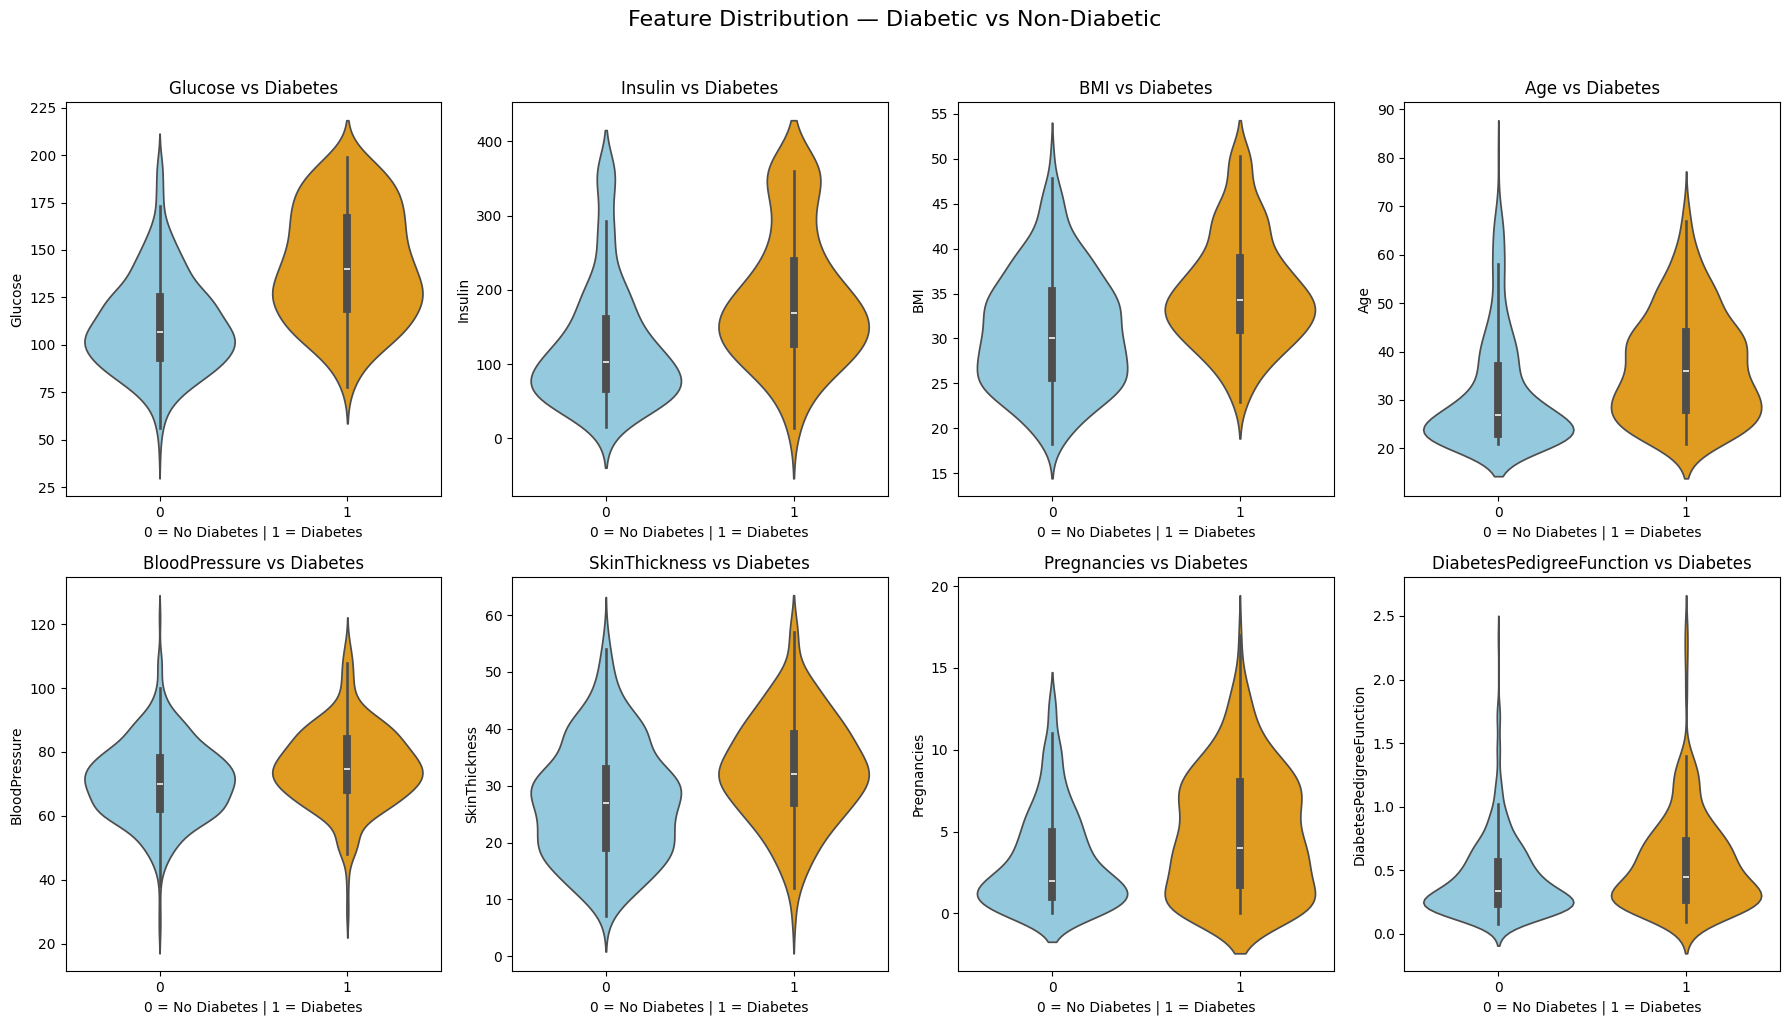

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['Glucose', 'Insulin', 'BMI', 'Age',
            'BloodPressure', 'SkinThickness',
            'Pregnancies', 'DiabetesPedigreeFunction']

for i, col in enumerate(features):
    sns.violinplot(x='Outcome', y=col, data=data,
                  ax=axes[i],
                  hue='Outcome',
                  palette={0:'skyblue', 1:'orange'},
                  legend=False)
    axes[i].set_title(f'{col} vs Diabetes')
    axes[i].set_xlabel('0 = No Diabetes | 1 = Diabetes')

plt.suptitle('Feature Distribution — Diabetic vs Non-Diabetic',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 🎻 Violin Plot Findings
- Glucose shows clearest separation between groups
- BloodPressure distributions nearly identical — weak predictor
- Age distributions differ — diabetic patients skew older

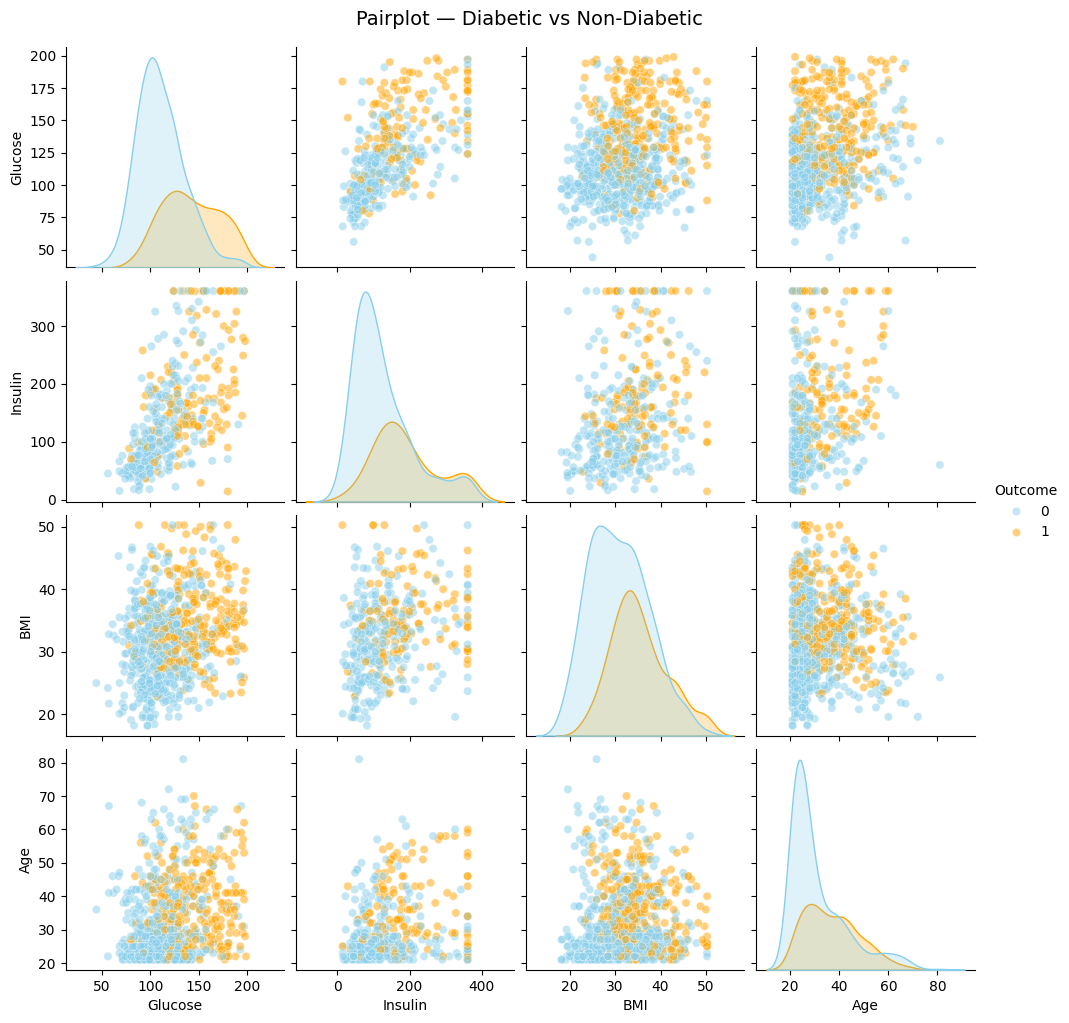

In [41]:
sns.pairplot(data[['Glucose', 'Insulin', 'BMI',
                  'Age', 'Outcome']],
             hue='Outcome',
             palette={0:'skyblue', 1:'orange'},
             diag_kind='kde',
             plot_kws={'alpha':0.5})

plt.suptitle('Pairplot — Diabetic vs Non-Diabetic',
             y=1.02, fontsize=14)
plt.show()

### 📊 Pairplot Findings
- Glucose diagonal shows strongest peak separation
- Age + Glucose combination best separates diabetic patients
- Insulin scatter plots heavily mixed — weak standalone predictor

###ML Modeling & Comparison


In [79]:
# Example dataset
features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

X = data[features]   # features
y = data['Outcome']   #Target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)

In [80]:
#Logistic Model
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [81]:
#KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

In [92]:
##  Decision Tree

dec_tree = DecisionTreeClassifier()
dec_tree.fit(X_train_scaled, y_train)

dec_pred = dec_tree.predict(X_test_scaled)

In [91]:
## Random Forest
random_forest = RandomForestClassifier()
random_forest.fit(X_train_scaled, y_train)

random_forest_pred = random_forest.predict(X_test_scaled)

In [94]:
log_accuracy = accuracy_score(y_test, log_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
dec_accuracy = accuracy_score(y_test, dec_pred)
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)

print("Logistic Regression Accuracy:", log_accuracy)
print("KNN Accuracy:", knn_accuracy)
print("DecisionTree Accuracy:", dec_accuracy)
print("Random Forest Accuracy:", random_forest_accuracy)

Logistic Regression Accuracy: 0.7532467532467533
KNN Accuracy: 0.7272727272727273
DecisionTree Accuracy: 0.6948051948051948
Random Forest Accuracy: 0.7402597402597403


####Based on the above accuracy results, the Logistic Regression model performs better than the other models because it provides the highest accuracy.

In [95]:
models = {
    "Logistic Regression": log_pred,
    "KNN": knn_pred,
    "Decision Tree": dec_pred,
    "Random Forest": random_forest_pred
}

In [96]:
results = []

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Confusion Matrix": cm
    })

In [97]:
results_df = pd.DataFrame(results)
results_df.round(3)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score  \
0  Logistic Regression  0.753247   0.666667  0.618182  0.641509   
1                  KNN  0.727273   0.603175  0.690909  0.644068   
2        Decision Tree  0.694805   0.568966  0.600000  0.584071   
3        Random Forest  0.740260   0.627119  0.672727  0.649123   

       Confusion Matrix  
0  [[82, 17], [21, 34]]  
1  [[74, 25], [17, 38]]  
2  [[74, 25], [22, 33]]  
3  [[77, 22], [18, 37]]  


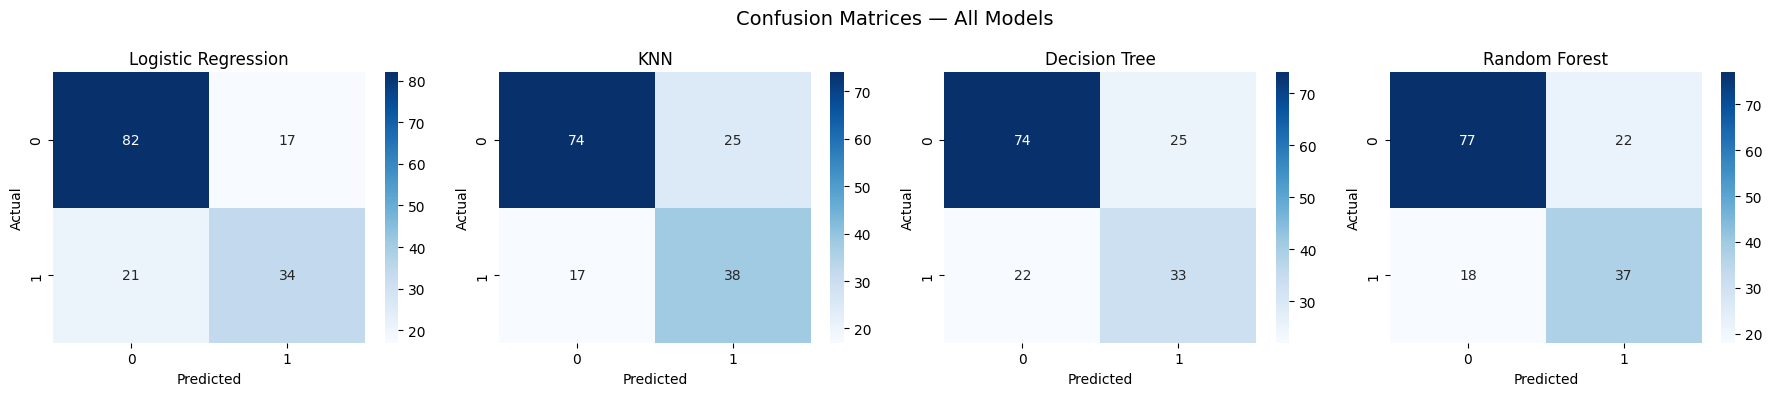

In [98]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d',
                cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.show()

## Model Evaluation Observation with Additional Features

After adding more features to the dataset, the performance of four models was re-evaluated: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Random Forest.

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|---------|-----------|--------|----------|
| Logistic Regression | 0.753 | 0.667 | 0.618 | 0.642 |
| KNN                 | 0.727 | 0.603 | **0.691** | 0.644 |
| Decision Tree       | 0.695 | 0.569 | 0.600 | 0.584 |
| Random Forest       | 0.740 | 0.627 | 0.673 | 0.649 |

**Observations:**

1. **Accuracy:** Logistic Regression still has the highest overall accuracy (0.753), meaning it correctly classifies the most total instances.  
2. **Recall:** KNN now has the highest recall (0.691), which indicates it is better at identifying positive cases (fewer false negatives).  
3. **F1-Score:** Random Forest still has the highest F1-score (0.649), showing a good balance between precision and recall.  
4. **Conclusion:** Depending on the objective:
   - If **catching all positive cases** is most important (e.g., disease detection), **KNN may be preferred** because of the highest recall.  
   - If **overall accuracy** is prioritized, **Logistic Regression remains strong**.  
   - If **balanced performance** is needed, **Random Forest is still a reliable choice**.